# Fano-factor quench magnitude vs (log) reaction time (session level)
Quench magnitude computed **exactly as in ff_quench** (peak-to-trough of smoothed FF in -0.2..0.2 s; positive = drop), averaged across neurons per session, correlated with per-session reaction time (default: mean log reaction time).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
ff_path = prefix + 'neural/fano_factor/psths_fanofactor_per_neuron_all_regions_25-06-2026'
clustering_dir = prefix + 'clustering/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'

REGION_FILTER = None       # None (all neurons, as in ff_quench) | 'drop_root' | list
RT_METRIC = 'log_rt_mean'  # 'log_rt_mean' | 'rt_median' | 'rt_mean'

summary_df = pd.read_parquet(ff_path)
lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
trials_df = pd.read_parquet(trials_path)

timestep_cols = sorted([c for c in summary_df.columns if c.startswith('time_')], key=lambda x: int(x.split('_')[1]))
time_in_seconds = np.linspace(-0.5, 1.0, len(timestep_cols))
bin_type = 'binned1'

def area_mask(a):
    if REGION_FILTER is None: return np.ones(len(a), dtype=bool)
    if REGION_FILTER == 'drop_root': return (a != 'root').values
    return a.isin(REGION_FILTER).values

print(f"neurons: {len(summary_df)}, sessions: {summary_df['session'].nunique()}")

neurons: 65374, sessions: 244


## Quench magnitude per neuron -> session (reproduced from ff_quench)

In [3]:
# ===== EXACT ff_quench quench-magnitude computation =====
sigma = 1
filtered = summary_df[area_mask(summary_df['area'])].copy()
filtered = filtered.merge(lda[[bin_type, 'session']], on='session')

t_mask = (time_in_seconds >= -0.2) & (time_in_seconds <= 0.2)
t_window = time_in_seconds[t_mask]

raw_matrix = filtered[timestep_cols].values.astype(float)
smoothed_matrix = gaussian_filter1d(raw_matrix, sigma=sigma, axis=1)

neuron_quenches = []
for i in range(len(filtered)):
    ts_win = smoothed_matrix[i, t_mask]
    search_window_mask = (t_window >= -0.2) & (t_window <= 0.2)

    peak_idx_local = np.argmax(ts_win[search_window_mask])
    i_peak = np.where(search_window_mask)[0][peak_idx_local]
    t_peak, v_peak = t_window[i_peak], ts_win[i_peak]

    min_idx_local = np.argmin(ts_win[search_window_mask])
    i_min = np.where(search_window_mask)[0][min_idx_local]
    t_min, v_min = t_window[i_min], ts_win[i_min]

    quench_val = (v_peak - v_min) if t_peak < t_min else (v_min - v_peak)
    neuron_quenches.append(quench_val)

filtered['neuron_quench'] = neuron_quenches
session_df = filtered.groupby('session')['neuron_quench'].mean().reset_index().rename(columns={'neuron_quench': 'quench'})
print(f"Quench magnitude for {len(session_df)} sessions; mean = {session_df['quench'].mean():.4f}")

Quench magnitude for 244 sessions; mean = 0.0673


## Reaction time per session

In [4]:
trials_df['log_reaction'] = np.log(trials_df['reaction'])
rt = trials_df.groupby('session').agg(
    rt_median=('reaction', 'median'),
    rt_mean=('reaction', 'mean'),
    log_rt_mean=('log_reaction', 'mean')).reset_index()
print(rt[['rt_median', 'rt_mean', 'log_rt_mean']].describe())

        rt_median     rt_mean  log_rt_mean
count  318.000000  318.000000   318.000000
mean     0.204540    0.959939    -1.467055
std      0.288830    0.875711     0.579568
min     -0.004427    0.019903    -2.753502
25%      0.121654    0.394869    -1.880650
50%      0.152028    0.653953    -1.539276
75%      0.190901    1.213352    -1.157803
max      3.352876    5.257630     0.388856


## Correlation: quench magnitude vs (log) reaction time

In [5]:
df = session_df.merge(rt, on='session', how='inner').merge(lda[['session', 'lda_1']], on='session', how='left')
df = df.dropna(subset=['quench', RT_METRIC])
r, p = pearsonr(df[RT_METRIC], df['quench'])
rho, pp = spearmanr(df[RT_METRIC], df['quench'])
print("="*60)
print(f"Quench magnitude vs reaction time ({RT_METRIC}), session level")
print("="*60)
print(f"n_sessions = {len(df)}")
print(f"pearson  r   = {r:+.3f}  p = {p:.3e}")
print(f"spearman rho = {rho:+.3f}  p = {pp:.3e}")

Quench magnitude vs reaction time (log_rt_mean), session level
n_sessions = 244
pearson  r   = -0.124  p = 5.395e-02
spearman rho = -0.208  p = 1.084e-03


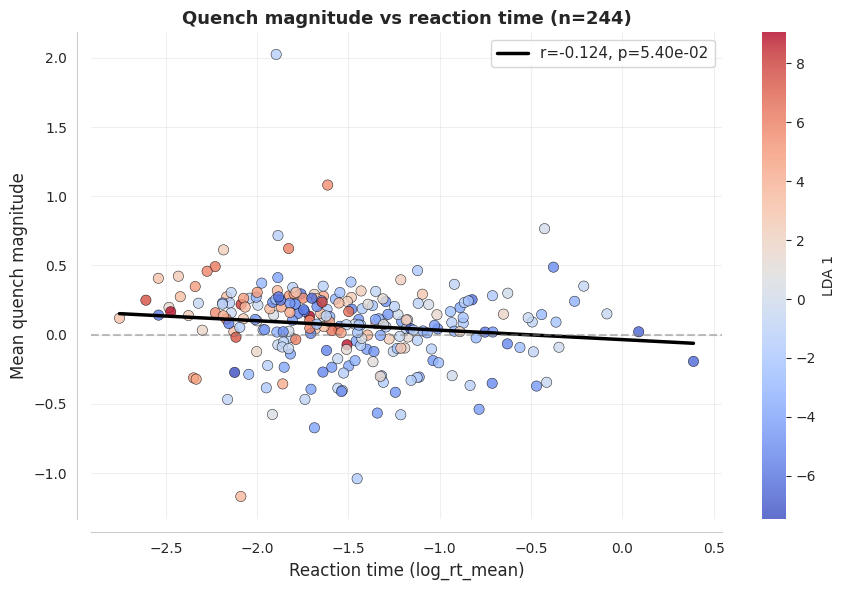

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
x = df[RT_METRIC].values; y = df['quench'].values
sc = ax.scatter(x, y, c=df['lda_1'].values, cmap='coolwarm', alpha=0.8, s=55, edgecolors='black', linewidth=0.4)
z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={r:.3f}, p={p:.2e}')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
cb = fig.colorbar(sc, ax=ax); cb.set_label('LDA 1'); cb.outline.set_visible(False)
ax.set_xlabel(f'Reaction time ({RT_METRIC})', fontsize=12)
ax.set_ylabel('Mean quench magnitude', fontsize=12)
ax.set_title(f'Quench magnitude vs reaction time (n={len(df)})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); sns.despine(ax=ax, offset=10)
plt.tight_layout(); plt.show()